In [1]:
import numpy as np
import scipy as sp
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal,norm
from collections import defaultdict
import warnings
import sklearn.exceptions
from scipy.special import erfinv
from sklearn.metrics import precision_score, recall_score, f1_score
from tqdm.notebook import tqdm
import os

from matplotlib.ticker import ScalarFormatter

from types import SimpleNamespace
import matplotlib.pyplot as plt

from _util import *

warnings.filterwarnings("ignore", category=sklearn.exceptions.ConvergenceWarning)

plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath} \usepackage{amssymb}'
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

np.set_printoptions(edgeitems=30, linewidth=100000, formatter=dict(float=lambda x: "%.3g" % x))


make_plot = lambda n,m,s=[1,1],sharex=False, sharey=False: plt.subplots(n,m,figsize=(m*3*s[0],n*2.5*s[1]),squeeze=False,layout='tight',sharex=sharex, sharey=sharey)

# Define your palettes
color_styles = [
    'k', 'b', 'r', 'g', 'c', 'm', 'y',]

line_styles = [
    '-', '--', '-.', ':'
]

def rank_approx(A, k,sort_type="big_small"):
    # Eigenvalue Decomposition (since A is symmetric, we can use eigh)
    eigenvalues, eigenvectors = np.linalg.eigh(A)
    
    # Sort eigenvalues and corresponding eigenvectors in descending order
    if sort_type == "big_small":
        idx = np.argsort(eigenvalues)[::-1]
    elif sort_type == "small_big":
        idx = np.argsort(eigenvalues)
    
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    # Select the top-k eigenvalues and eigenvectors
    top_eigenvalues = np.diag(eigenvalues[:k])
    top_eigenvectors = eigenvectors[:, :k]
    
    # Reconstruct the rank-k approximation
    A_k = top_eigenvectors @ top_eigenvalues @ top_eigenvectors.T
    
    return A_k


def print_eig(matrix):

    # Validate symmetry
    if not np.allclose(matrix, matrix.T):
      raise ValueError("Error: The matrix is not symmetric.")
    
    # Compute eigenvalues and eigenvectors using an algorithm optimized for symmetric matrices
    eigenvalues, eigenvectors = np.linalg.eigh(matrix)
    
    # Sort eigenvalues and corresponding eigenvectors in ascending order.
    sorted_indices = np.argsort(eigenvalues)
    sorted_eigenvalues = eigenvalues[sorted_indices]
    sorted_eigenvectors = eigenvectors[:, sorted_indices]
    
    # Create a DataFrame where each column header is a sorted eigenvalue,
    # and the column entries are the corresponding eigenvector components.
    df = pd.DataFrame(sorted_eigenvectors, columns=[f"{val:.4f}" for val in sorted_eigenvalues])
    
    # Append the final row labeled "sum" with the sum of each column (eigenvector)
    df.loc['sum'] = df.sum(axis=0)
    
    # Configure Pandas display options to avoid wrapping the DataFrame after a set number of columns.
    pd.set_option('display.max_columns', None)
    pd.set_option('display.expand_frame_repr', False)
    
    # Print the table to the console.
    print("Eigenvalue Table:")
    print(df)

def compute_metrics(result, C_true, iC_true, Y):

    if result is None or np.isnan(np.sum(result.iC)):
        result_metrics = {
            'err_C': np.nan,
            'err_iC': np.nan,
            'err_S': np.nan,
            'nnz': np.nan,
            'nll': np.nan,
            'sphr': np.nan,
            'precision': np.nan,
            'recall': np.nan,
            'f1': np.nan,
            'kl': np.nan,
            'aic':np.nan,
            'runtime': np.nan
        }
        return SimpleNamespace(**result_metrics)

    p, n = Y.shape
    S   = np.cov(Y, bias=True)
    C   = result.C + np.eye(p) * 1e-6
    iC  = result.iC + np.eye(p) * 1e-6

    # Use X if available, otherwise default to iC
    X = result.X if hasattr(result, "X") else iC
    X[np.abs(X) < 1e-10] = 0

    # Compute error metrics on covariance/precision matrices
    err_C  = np.linalg.norm(C  - C_true, ord="fro")**2 / np.linalg.norm(C_true, ord="fro")**2
    err_iC = np.linalg.norm(iC - iC_true, ord="fro")**2 / np.linalg.norm(iC_true, ord="fro")**2
    err_S  = np.linalg.norm(C  - S, ord="fro")**2
    nnz    = (np.count_nonzero(X)-p) / p
    
    (sign, logdet) = np.linalg.slogdet(iC)
    nll = - (sign * logdet) + np.trace(iC @ S)

    sphr   = p * np.trace(X @ X) / np.trace(X)**2 - 1 
    aic    =  nll + nnz/2 + p

    # Compute KL divergence loss for two zero-mean Gaussians.
    # KL = 0.5 * (trace(iC @ C_true) - p + log(det(C) / det(C_true)))
    kl = 0.5 * (np.trace(iC @ C_true) - p + np.log(np.linalg.det(C) / np.linalg.det(C_true)))
    
    # Compute F1 score for structure recovery of the precision matrix.
    # Threshold the absolute values to define nonzero connections.
    tol = 1e-5
    est_support = np.abs(iC) > tol
    true_support = np.abs(iC_true) > tol

    # Exclude the diagonal entries from evaluation.
    np.fill_diagonal(est_support, False)
    np.fill_diagonal(true_support, False)

    # Flatten binary matrices into 1D arrays.
    y_true = true_support.flatten()
    y_pred = est_support.flatten()

    # Compute the metrics using scikit-learn.
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    # Compile all computed metrics into a structured object.
    result_metrics = {
        'err_C': err_C,
        'err_iC': err_iC,
        'err_S': err_S,
        'nnz': nnz,
        'nll': nll,
        'sphr': sphr,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'kl': kl,
        'aic':aic,
        'runtime': result.runtime
    }
    return SimpleNamespace(**result_metrics)

def metrics_list(results):
    if len(results)<1:
        return []
    if isinstance(results, list) and results:
        # Dynamically retrieve keys from the first result (e.g., 'err_C', 'err_iC', etc.)
        keys = vars(results[0]).keys()
        aggregated = {key: [getattr(r, key) for r in results] for key in keys}
        return SimpleNamespace(**aggregated)
    else:
        return results

During startup - Warning messages:
1: Setting LC_COLLATE failed, using "C" 
2: Setting LC_TIME failed, using "C" 
3: Setting LC_MESSAGES failed, using "C" 
4: Setting LC_MONETARY failed, using "C" 


# Fig 1

In [ ]:
fig, axs = make_plot(1,2,s=[1.2,1],sharex=False, sharey=False)

#########################
#########################
inx = 0
#########################
#########################
mu = 1
sigma = 1
x = np.linspace(-4, 4, 1000)

pdf_normal = sp.stats.norm.pdf(x, mu, sigma)
c = abs(mu / sigma)

pdf_folded  = sp.stats.foldnorm.pdf(x, c, scale=sigma)
mean_folded = sp.stats.foldnorm.mean(c, scale=sigma)

# Normal distribution
axs[0,inx].plot(x, pdf_normal, label=r"$X\sim\mathcal{N}(1,1)$", color="black",linestyle="-",linewidth=2)
axs[0,inx].fill_between(x[x < 0], pdf_normal[x < 0], color='black', alpha=0.1)
axs[0,inx].plot(x, pdf_folded, label=r"$|X|$", color="blue",linestyle="--",linewidth=2)

# Highlighting how negative side maps to positive side in folded normal
axs[0,inx].fill_between(x[x>0],pdf_folded[x > 0], pdf_normal[x > 0], color='black', alpha=0.1)

# Mean lines
axs[0,inx].axvline(mu, color='black', label=r"$|\mathbb{E}[X]|$",linestyle="-",linewidth=1)
#axs[0,inx].axvline(mean_folded, color='blue', label=r"$\mathbb{E}[|X|]$",linestyle="--",linewidth=1)

axs[0, inx].set_xlabel(r'Value of $X$ or $|X|$')
axs[0, inx].set_ylabel(r'Density')
axs[0, inx].legend(loc='upper left',frameon=False,fontsize=10)

#########################
#########################
inx = inx + 1
#########################
#########################
alpha_set = [0.0, 0.2, 0.4, 0.6, 0.8, 0.90, 0.95, 0.99, 1.0]
v = 1.5
k = 20
f = lambda L, alpha: 1 - 0.5 * (
    sp.special.erf((L - alpha * L) / np.sqrt(2 * v / k)) +
    sp.special.erf((L + alpha * L) / np.sqrt(2 * v / k))
)

# Assume axs and inx are already defined
x = np.linspace(0, 1, 1000)

for alpha in alpha_set[1:-1]:
    y = f(x, alpha)
    axs[0, inx].plot(x, y, linestyle='-', linewidth=1, color='gray', alpha=0.5)

axs[0, inx].plot(x, f(x, 1.0), label=r"$|\mathbf{\bar{G}}_{\scriptscriptstyle{ij}}| = \mathbf{\Lambda}_{\scriptscriptstyle{ij}}$",          color="black", linestyle="-", linewidth=2)
axs[0, inx].plot(x, f(x, 0.9), label=r"$|\mathbf{\bar{G}}_{\scriptscriptstyle{ij}}| = 0.9 \cdot \mathbf{\Lambda}_{\scriptscriptstyle{ij}}$",color="blue", linestyle="--", linewidth=2)
axs[0, inx].plot(x, f(x, 0.5), label=r"$|\mathbf{\bar{G}}_{\scriptscriptstyle{ij}}| = 0.5 \mathbf{\Lambda}_{\scriptscriptstyle{ij}}$",      color="red", linestyle="-.", linewidth=2)
axs[0, inx].plot(x, f(x, 0.0), label=r"$|\mathbf{\bar{G}}_{\scriptscriptstyle{ij}}| = 0$",color="green", linestyle=":", linewidth=2)
axs[0, inx].fill_between(x, f(x, 0.0), f(x, 1.0),color='orange', alpha=0.1,label=r"$0<|\mathbf{\bar{G}}_{\scriptscriptstyle{ij}}|<\mathbf{\Lambda}_{\scriptscriptstyle{ij}}$")

# axs[0, inx].set_ylabel(r"Probability $\textrm{Pr}[|\bar{\mathbf{G}}_{\scriptscriptstyle{ij}}^{(k)}| > \mathbf{\Lambda}_{\scriptscriptstyle{ij}}]$")
#axs[0, inx].set_ylabel(r"Cumulative Prob. $\textrm{F}(\mathbf{\Lambda}_{\scriptscriptstyle{ij}};\mathbf{\bar{G}}_{\scriptscriptstyle{ij}})$")
axs[0, inx].set_ylabel(r"Selection Probability")
axs[0, inx].set_xlabel(r"Regularization Parameter $\mathbf{\Lambda}_{\scriptscriptstyle{ij}}$")

axs[0, inx].set_ylim([0, 1.18])
axs[0, inx].set_xlim([0, np.max(x)])
axs[0, inx].legend(loc='upper right', frameon=False, fontsize=9, ncol=2,labelspacing=0.3,columnspacing=0.8)


fig.savefig("fig_1.png", dpi=300)

fig_size_pixels = fig.get_size_inches()
print("Figure size (width x height in pixels):", fig_size_pixels, fig_size_pixels[1] / fig_size_pixels[0])

# Fig 2

In [ ]:
def test1(p=128, N=1000, gamma=1/100, data_method='cluster'):

    n = int(p*20)
    k = int(n/2)

    # Precompute covariance and data
    iC_true, C_true = make_cov(p, data_type=data_method, seed=1)
    Y = make_samples(cov=C_true, n=n, seed=1)
    Y, _, _ = normalize_data(Y)
    S = np.cov(Y, bias=True)

    # Aquic result
    res_aquic = compute_aquic(Y, k=k, gamma=gamma, clip_gamma=False)
    iC = res_aquic.iC
    C  = res_aquic.C

    print("num nnzpr =", np.count_nonzero(iC) / p)

    # Precompute threshold matrix L
    diagS = np.diagonal(S)
    V = S**2 + np.outer(diagS, diagS)
    L = sp.special.erfinv(1.0 - 2.0 * gamma) / 2.0 * np.sqrt(2.0 * V / k)
    np.fill_diagonal(L, 1e-12)

    # Vectorized probability matrix P
    P = np.zeros((p, p))
    for i in range(N):
        
        #inx_k = np.random.choice(int(n), size=int(k), replace=False)
        inx_k = np.random.choice(int(n), size=int(k))
        Y_k = Y[:, inx_k]
        #Y_k = make_samples(cov=C_true, n=int(k), seed=i)
        #Y_k, _, _ = normalize_data(Y_k)

        S_k = np.cov(Y_k, bias=True)
        G_k = S_k - C
        np.fill_diagonal(G_k, 0.0)
        P += (np.abs(G_k) >= L)

    P /= N

    mask_nnz  = iC != 0
    mask_triu = np.triu(np.ones((p, p), dtype=bool), k=1)
    pr_nnz = P[mask_nnz & mask_triu].tolist()
    iC_nnz = iC[mask_nnz & mask_triu].tolist()
    pr_z   = P[~mask_nnz & mask_triu].tolist()
    iC_z   = iC[~mask_nnz & mask_triu].tolist()

    return pr_nnz, pr_z, iC_nnz, iC_z

def test2(p=128, n=None, k=None, data_method="cluster", gamma_set=None, N=100, seed=1):
  
    # Storage for results
    nnz_results = np.zeros((N, len(gamma_set)))
    iC_true, C_true = make_cov(p, data_type=data_method, seed=0)
    
    for i in range(N):
        # Generate true covariance and samples for each experiment

        Y = make_samples(cov=C_true, n=int(n), seed=i)

        for j, gamma in enumerate(gamma_set):
            res_aquic = compute_aquic(Y, k=k, gamma=gamma, clip_gamma=False)

            # Count off-diagonal nonzeros per row
            iC = res_aquic.iC.copy()
            np.fill_diagonal(iC, 0)  # Ignore diagonal
            nnz_results[i, j] = np.count_nonzero(iC) / p

    # Compute mean and std across N runs
    nnz_mean = nnz_results.mean(axis=0)
    nnz_std = nnz_results.std(axis=0)

    return nnz_mean, nnz_std


fig, axs = make_plot(1,2,s=[1.2,1],sharex=False, sharey=False)

#########################
#########################
inx = 0
#########################
#########################
p = 128
data_method = "cluster"

for color, linestyle, gamma in [ ('black', '-' , 0.01),('blue' , '--', 0.1),('red',  '-.' , 0.2)]:
    pr_nnz, pr_z, iC_nnz, iC_z = test1(p=p, gamma=gamma, data_method=data_method, N=1000)
    axs[0, inx].plot(iC_nnz,pr_nnz,linestyle='None',marker='.',color=color,alpha=0.1,label="_")
    axs[0, inx].axhline(y=(0.5 + gamma), color=color, linewidth=1, linestyle=linestyle, alpha=1, label=rf'$\gamma={gamma}$')

axs[0, inx].set_ylabel(r'Empirical Reselection Prob.')
axs[0, inx].set_xlabel(r'Magnitude of Nonzero Entries $|\mathbf{\hat{\Theta}}_{\scriptscriptstyle{ij}}|$')

axs[0, inx].set_ylim([0.45,1.0])
axs[0, inx].set_xlim([0.0,0.4])
axs[0, inx].legend(loc='upper right',frameon=False,fontsize=9,ncol=1)


#########################
#########################
inx = inx+1
#########################
#########################

data_method = "cluster"
gamma_min = 1e-6
gamma_max = 0.088  

p = 32
n = p/2
k = n/2
gamma_set = np.linspace(gamma_min, gamma_max, 10)
nnz_mean, nnz_std = test2(p=p, n=n, k=k, data_method=data_method, gamma_set=gamma_set, N=100, seed=1)
nnz_min = nnz_mean - nnz_std*2
nnz_max = nnz_mean + nnz_std*2

axs[0, inx].plot(gamma_set, nnz_mean, color="black", alpha=1, linestyle='-',  marker='', linewidth=2, label=rf"$p={p}$")
# axs[0, inx].plot(gamma_set, nnz_min,  color="black", alpha=1, linestyle='--', marker='', linewidth=1, label=r"_$\pm \mathrm{{std}}$")
# axs[0, inx].plot(gamma_set, nnz_max,  color="black", alpha=1, linestyle='--', marker='', linewidth=1, label="_")
# axs[0, inx].fill_between(gamma_set, nnz_min, nnz_max, color='orange', alpha=0.1,label=r"_")


p = 64
n = p/2
k = n/2
gamma_set = np.linspace(gamma_min, gamma_max, 10)
nnz_mean, nnz_std = test2(p=p, n=n, k=k, data_method=data_method, gamma_set=gamma_set, N=100, seed=1)
nnz_min = nnz_mean - nnz_std*2
nnz_max = nnz_mean + nnz_std*2

axs[0, inx].plot(gamma_set, nnz_mean, color="blue", alpha=1, linestyle='--',  marker='', linewidth=2, label=rf"$p={p}$")
# axs[0, inx].plot(gamma_set, nnz_min,  color="black", alpha=1, linestyle='--', marker='', linewidth=1, label=r"_$\pm \mathrm{{std}}$")
# axs[0, inx].plot(gamma_set, nnz_max,  color="black", alpha=1, linestyle='--', marker='', linewidth=1, label="_")
# axs[0, inx].fill_between(gamma_set, nnz_min, nnz_max, color='orange', alpha=0.1,label=r"_")


p = 128
n = p/2
k = n/2
gamma_set = np.linspace(gamma_min, gamma_max, 10)
nnz_mean, nnz_std = test2(p=p, n=n, k=k, data_method=data_method, gamma_set=gamma_set, N=100, seed=1)
nnz_min = nnz_mean - nnz_std*2
nnz_max = nnz_mean + nnz_std*2

axs[0, inx].plot(gamma_set, nnz_mean, color="red", alpha=1, linestyle='-.',  marker='', linewidth=2, label=rf"$p={p}$")
# axs[0, inx].plot(gamma_set, nnz_min,  color="black", alpha=1, linestyle='--', marker='', linewidth=1, label=r"_$\pm \mathrm{{std}}$")
# axs[0, inx].plot(gamma_set, nnz_max,  color="black", alpha=1, linestyle='--', marker='', linewidth=1, label="_")
# axs[0, inx].fill_between(gamma_set, nnz_min, nnz_max, color='orange', alpha=0.1,label=r"_")


p = 256
n = p/2
k = n/2
gamma_set = np.linspace(gamma_min, gamma_max, 10)
nnz_mean, nnz_std = test2(p=p, n=n, k=k, data_method=data_method, gamma_set=gamma_set, N=100, seed=1)
nnz_min = nnz_mean - nnz_std*2
nnz_max = nnz_mean + nnz_std*2

axs[0, inx].plot(gamma_set, nnz_mean, color="green", alpha=1, linestyle=':',  marker='', linewidth=2, label=rf"$p={p}$")
# axs[0, inx].plot(gamma_set, nnz_min,  color="black", alpha=1, linestyle='--', marker='', linewidth=1, label=r"_$\pm \mathrm{{std}}$")
# axs[0, inx].plot(gamma_set, nnz_max,  color="black", alpha=1, linestyle='--', marker='', linewidth=1, label="_")
# axs[0, inx].fill_between(gamma_set, nnz_min, nnz_max, color='orange', alpha=0.1,label=r"_")

axs[0, inx].set_ylabel(r'Nonzeros Per Row')
axs[0, inx].set_xlabel(r'Parameter $\gamma$')

xticks = np.linspace(gamma_set[0], gamma_set[-1], 5)
axs[0, inx].set_xticks(xticks)

axs[0, inx].set_ylim([0,40])

axs[0, inx].legend(loc='upper left',frameon=False,fontsize=9,ncol=1)

fig.savefig("fig_2.png", dpi=300)

fig_size_pixels = fig.get_size_inches()
print("Figure size (width x height in pixels):", fig_size_pixels, fig_size_pixels[1] / fig_size_pixels[0])

# Fig 3

In [ ]:
def test_1(iC_true, C_true,n,k,c,seed=0):

    p     = iC_true.shape[0]

    Y      = make_samples(cov=C_true, n=int(n), seed=seed)
    Y,_,_  = normalize_data(Y)
    S      = np.cov(Y,bias=True)

    c_max = (p-1.)/2.
    c     = np.clip(c, 1, c_max-1)
    val   = 1. - c / (2. * (p-c-1.))
    gamma = 0.5 * (1. - sp.special.erf(2. * sp.special.erfinv(val)))
    
    gamma = np.clip(gamma, 1e-16, 0.5 - 1e-16)

    k     = k
    diagS = np.diagonal(S)                         
    V     = S**2 + np.outer(diagS, diagS)              
    L     = sp.special.erfinv(1.0 - 2.0 * gamma) / 2.0 * np.sqrt( 2.0 * V / k)
    np.fill_diagonal(L, 1e-12)

    res_aquic = compute_aquic(Y,c=c,k=k)

    C  = res_aquic.W
    iC = res_aquic.X

    nnzpr_actual = (np.count_nonzero(iC)      - p)/p
    nnzpr_true   = (np.count_nonzero(iC_true) - p)/p

    N = 100
    nnzpr_set = np.zeros(N)

    for i in range(N):
        
        inx_k   = np.random.choice(int(n), size=int(k),replace=False)
        Y_k     = Y[:, inx_k]
        #Y_k,_,_ = normalize_data(Y_k)

        S_k   = np.cov(Y_k, bias=True)
        G_k   = S_k - C
        P     = (np.abs(G_k) >= L) * 1.0
        np.fill_diagonal(P, 1.0)

        nnzpr_set[i] = (np.sum(P) - p)/p
    
    return nnzpr_set,nnzpr_actual,nnzpr_true,gamma

def test_2(c, p_line, data_type,seed=0):
    
    nnz      = np.zeros(len(p_line))
    nnz_true = np.zeros(len(p_line))

    # Metrics for sample-based run (method=1)
    nnz_sample_avg = np.zeros(len(p_line))
    nnz_sample_std = np.zeros(len(p_line))
    
    gamma_set = np.zeros(len(p_line))

    for inx, p in enumerate(p_line):

        print('--> p',p)
        n = int(p / 2)  # Assuming n is half of p
        k = int(n / 2)  # Assuming k is half of n

        # Generate true covariance and data
        iC_true, C_true = make_cov(p, data_type=data_type,seed=inx)
        Y               = make_samples(cov=C_true, n=int(n), seed=inx)

        # Compute AQUIC estimate and metrics
        res_aquic     = compute_aquic(Y, c=c, k=k)
        met_aquic     = compute_metrics(res_aquic, C_true, iC_true, Y)
        s             = (np.count_nonzero(res_aquic.iC) - p) / p
        nnz[inx]      = s
        nnz_true[inx] = (np.count_nonzero(iC_true) - p) / p

        # Sample-based run us n_sampling = 1000 x p 
        n_s = n 
        k_s = k 
        nnzpr_set, nnzpr_actual, nnzpr_true,gamma = test_1(iC_true, C_true, n_s, k_s, c, inx)
        nnz_sample_avg[inx] = np.mean(nnzpr_set)
        nnz_sample_std[inx] = np.std(nnzpr_set)
        gamma_set[inx]      = gamma

        print('->', np.min(nnzpr_set) , np.mean(nnzpr_set),np.max(nnzpr_set))

    return (
        nnz,
        nnz_true,
        nnz_sample_avg,
        nnz_sample_std
    )

def test_3(p, n, k, c_line, data_type,seed=0):
    
    # Generate true covariance and data
    iC_true, C_true = make_cov(p, data_type=data_type,seed=seed)
    Y               = make_samples(cov=C_true, n=int(n), seed=seed)

    nnz             = np.zeros(len(c_line))
    nnz_true        = np.zeros(len(c_line))

    # Metrics for sample-based run (method=1)
    nnz_sample_avg = np.zeros(len(c_line))
    nnz_sample_std = np.zeros(len(c_line))
    
    gamma_set = np.zeros(len(c_line))

    for inx, c in enumerate(c_line):

        print('--> c',c)
        
        # Compute AQUIC estimate and metrics
        res_aquic     = compute_aquic(Y, c=c, k=k)
        met_aquic     = compute_metrics(res_aquic, C_true, iC_true, Y)
        s             = (np.count_nonzero(res_aquic.iC) - p) / p
        nnz[inx]      = s
        nnz_true[inx] = (np.count_nonzero(iC_true) - p) / p

        # Sample-based run us n_sampling = 1000 x p 
        n_s = n 
        k_s = k 
        nnzpr_set, nnzpr_actual, nnzpr_true,gamma = test_1(iC_true, C_true, n_s, k_s, c,inx)
        nnz_sample_avg[inx] = np.mean(nnzpr_set)
        nnz_sample_std[inx] = np.std(nnzpr_set)
        gamma_set[inx] = gamma

        print('->', np.min(nnzpr_set) , np.mean(nnzpr_set),np.max(nnzpr_set))

    return (
        nnz,
        nnz_true,
        nnz_sample_avg,
        nnz_sample_std
    )

def test_4(gamma, p_line, data_type,seed=0):
  
    nnz             = np.zeros(len(p_line))
    nnz_true        = np.zeros(len(p_line))

    # Metrics for sample-based run (method=1)
    nnz_sample_avg = np.zeros(len(p_line))
    nnz_sample_std = np.zeros(len(p_line))
    
    for inx, p in enumerate(p_line):

        print('--> p',p)
        n = int(p / 2)  # Assuming n is half of p
        k = int(n / 2)  # Assuming k is half of n

        # Generate true covariance and data
        iC_true, C_true = make_cov(p, data_type=data_type,seed=inx)
        Y               = make_samples(cov=C_true, n=int(n), seed=inx)

        # Compute AQUIC estimate and metrics
        res_aquic     = compute_aquic(Y, gamma=gamma, k=k, clip_gamma=False)
        met_aquic     = compute_metrics(res_aquic, C_true, iC_true, Y)
        s             = (np.count_nonzero(res_aquic.iC) - p) / p
        nnz[inx]      = s
        nnz_true[inx] = (np.count_nonzero(iC_true) - p) / p

    return (
        nnz,
        nnz_true,
    )

########################################
# Plot
########################################
fig, axs = make_plot(1,2,s=[1.2,1],sharex=False, sharey=False)
data_type   = 'cluster'
line_style  = ['-', '--', '-.', ':']
color_style = ['k', 'b', 'r', 'g']

########################################
inx = 0
########################################
p_line = np.array([64, 128, 256, 512, 1024])

# nnz, nnz_true, nnz_sample_avg, nnz_sample_std = test_2(c=c,        p_line=p_line, data_type=data_type,seed=0)
# nnz_fix, nnz_true_fix                         = test_4(gamma=0.06, p_line=p_line, data_type=data_type,seed=0)

# nnz_sample_min = nnz_sample_avg - nnz_sample_std*1
# nnz_sample_max = nnz_sample_avg + nnz_sample_std*1

# axs[0,inx].semilogx(p_line,nnz_sample_avg,                      color="black",   alpha=1.0, linestyle='-',  marker='', linewidth=2, label=r"$\bar{z} \pm \mathrm{std}$")
# axs[0,inx].semilogx(p_line,nnz_sample_min,                      color="black",   alpha=1.0, linestyle='-',  marker='', linewidth=1, label=r"_")
# axs[0,inx].semilogx(p_line,nnz_sample_max,                      color="black",   alpha=1.0, linestyle='-',  marker='', linewidth=1, label=r"_")
# axs[0,inx].fill_between(p_line, nnz_sample_min, nnz_sample_max, color='orange',  alpha=0.1,                                         label=r"_")

# axs[0,inx].semilogx(p_line,nnz,                                 color="blue",    alpha=1.0, linestyle='--', marker='', linewidth=2, label=rf"$s$ with ($c={c}$)")
# axs[0,inx].semilogx(p_line,nnz_fix,                             color="green",   alpha=1.0, linestyle='-.', marker='', linewidth=2, label=r"$s$ with (fixed $\gamma=0.06$)")

# axs[0,inx].axhline(y=c,                                         color="red",     alpha=1.0, linestyle="-",             linewidth=1, label=r"c")
# axs[0,inx].axhline(y=np.mean(nnz_true),                         color="magenta", alpha=1.0, linestyle=":",             linewidth=1, label=r"$s_\text{true}$")
# axs[0,inx].plot(p_line,(c+np.array(nnz))/2.,                    color="orange",  alpha=1.0, linestyle=":",             linewidth=1, label=r"$\tfrac{1}{2}(s+c)$")


# y_line = np.linspace(0, 60, 6, endpoint=True)
# axs[0,inx].set_yticks(y_line)
# axs[0,inx].set_yticklabels([str(int(x)) for x in y_line])
# axs[0,inx].set_ylim([-1,max(y_line)])

# # axs[0,inx].minorticks_on()

# axs[0,inx].set_xscale("log", base=2)
# axs[0,inx].set_xticks(p_line)
# axs[0,inx].set_xticklabels([str(int(x)) for x in p_line])

# axs[0,inx].set_ylabel(r"Values Per Row")
# axs[0,inx].set_xlabel(r"Dimension ($p$)")
# axs[0,inx].legend(loc='upper left',frameon=False, fontsize=9, ncol=2)


c = 10
nnz, nnz_true, nnz_sample_avg, nnz_sample_std = test_2(c=c, p_line=p_line, data_type=data_type,seed=0)
axs[0,inx].semilogx(p_line,nnz, color="black", alpha=1.0, linestyle='-', marker='', linewidth=2, label=rf"$c={c}$")

c = 20
nnz, nnz_true, nnz_sample_avg, nnz_sample_std = test_2(c=c, p_line=p_line, data_type=data_type,seed=0)
axs[0,inx].semilogx(p_line,nnz, color="black", alpha=1.0, linestyle='--', marker='', linewidth=2, label=rf"$c={c}$")

c = 30
nnz, nnz_true, nnz_sample_avg, nnz_sample_std = test_2(c=c, p_line=p_line, data_type=data_type,seed=0)
axs[0,inx].semilogx(p_line,nnz, color="black", alpha=1.0, linestyle='-.', marker='', linewidth=2, label=rf"$c={c}$")

axs[0,inx].axhline(y=np.mean(nnz_true), color="magenta", alpha=1.0, linestyle=":", linewidth=1, label=r"$s_\text{true}$")

gamma = .01
nnz, nnz_true  = test_4(gamma=gamma, p_line=p_line, data_type=data_type,seed=0)
axs[0,inx].semilogx(p_line,nnz, color="blue", alpha=1.0, linestyle='-', marker='', linewidth=2, label=rf"$\gamma={gamma:.2f}$")

gamma = .04
nnz, nnz_true  = test_4(gamma=gamma, p_line=p_line, data_type=data_type,seed=0)
axs[0,inx].semilogx(p_line,nnz, color="blue", alpha=1.0, linestyle='--', marker='', linewidth=2, label=rf"$\gamma={gamma:.2f}$")

gamma = .06
nnz, nnz_true  = test_4(gamma=gamma, p_line=p_line, data_type=data_type,seed=0)
axs[0,inx].semilogx(p_line,nnz, color="blue", alpha=1.0, linestyle='-.', marker='', linewidth=2, label=rf"$\gamma={gamma:.2f}$")

y_line = [0,10,20,30,40,50]
axs[0,inx].set_yticks(y_line)
axs[0,inx].set_yticklabels([str(int(x)) for x in y_line])
axs[0,inx].set_ylim([-1,max(y_line)])

# axs[0,inx].minorticks_on()

axs[0,inx].set_xscale("log", base=2)
axs[0,inx].set_xticks(p_line)
axs[0,inx].set_xticklabels([str(int(x)) for x in p_line])

axs[0,inx].set_ylabel(r"Nonzeros Per Row $s$")
axs[0,inx].set_xlabel(r"Dimension $p$")
axs[0,inx].legend(loc='upper left',frameon=False, fontsize=9, ncol=2)


# break 

########################################
inx = inx + 1
########################################
p = 128

z_target_line = np.array([1,2,4,8,16,32,64])
iC_true, C_true = make_cov(p, data_type=data_type)
s_true = (np.count_nonzero(iC_true) - p) / p

axs[0, inx].axhline(
    y=s_true,
    color="magenta",
    alpha=1,
    linestyle=":",
    linewidth=1,
    label=r"$s_\text{true}$"
)


r_set = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 2.0, 3.0]
for i, r in enumerate(r_set):
    n = p * r
    k = n / 2.0
    nnz, nnz_true, nnz_sample_avg, nnz_sample_std = test_3(p,n,k,z_target_line, data_type,seed=i)
    nnz_sample_min = nnz_sample_avg - nnz_sample_std*2
    nnz_sample_max = nnz_sample_avg + nnz_sample_std*2

    axs[0,inx].loglog(z_target_line,nnz, color="gray", alpha=.5, linestyle='-',  marker='', linewidth=2 , zorder=1 , label=rf"_")
    print(" - r ", r, "nnz = ",nnz)

r = r_set[0]
n = p * r
k = n / 2.0
nnz, nnz_true, nnz_sample_avg, nnz_sample_std = test_3(p,n,k,z_target_line, data_type,seed=0)
nnz_sample_min = nnz_sample_avg - nnz_sample_std*2
nnz_sample_max = nnz_sample_avg + nnz_sample_std*2

axs[0,inx].loglog(z_target_line,nnz, color="black", alpha=1, linestyle='-',  marker='', linewidth=2 , label=rf"$n={n:.0f}$")
print("nnz = ",nnz)

r = .5
n = p * r
k = n / 2.0
nnz, nnz_true, nnz_sample_avg, nnz_sample_std = test_3(p,n,k,z_target_line, data_type,seed=0)
nnz_sample_min = nnz_sample_avg - nnz_sample_std*2
nnz_sample_max = nnz_sample_avg + nnz_sample_std*2
axs[0,inx].loglog(z_target_line,nnz, color="black", alpha=1, linestyle='--',  marker='', linewidth=2 , label=rf"$n={n:.0f}$")
print("nnz = ",nnz)

r = r_set[-1]
n = p * r
k = n / 2.0
nnz, nnz_true, nnz_sample_avg, nnz_sample_std = test_3(p,n,k,z_target_line, data_type,seed=0)
nnz_sample_min = nnz_sample_avg - nnz_sample_std*2
nnz_sample_max = nnz_sample_avg + nnz_sample_std*2
axs[0,inx].loglog(z_target_line,nnz, color="black", alpha=1, linestyle='-.',  marker='', linewidth=2 , label=rf"$n={n:.0f}$")
print("nnz = ",nnz)

axs[0,inx].loglog(z_target_line,np.clip(z_target_line,s_true,(p-1)/2), color="blue", alpha=1, linestyle=":",  marker='', linewidth=2 , label=r"$\textrm{max}(c,s_\text{true})$")

axs[0,inx].set_ylim([np.min(z_target_line),np.max(z_target_line)])
axs[0,inx].set_xlim([np.min(z_target_line),np.max(z_target_line)])
axs[0,inx].set_xticks(z_target_line)
axs[0,inx].set_yticks(z_target_line)
axs[0,inx].set_ylabel(z_target_line)
axs[0,inx].set_xlabel(z_target_line)

axs[0,inx].set_yscale("log", base=2)
axs[0,inx].set_xscale("log", base=2)

# Force tick labels to be plain numbers
y_line = [1,4,16,64]
axs[0,inx].set_yticks(y_line)
axs[0,inx].set_yticklabels([str(int(x)) for x in y_line])
axs[0,inx].set_ylim([min(y_line),max(y_line)])

x_line = [1,4,16,64]
axs[0,inx].set_xticks(x_line)
axs[0,inx].set_xticklabels([str(int(x)) for x in x_line])
axs[0,inx].set_xlim([min(x_line),max(x_line)])

axs[0,inx].set_ylabel(r"Nonzeros Per Row $s$")
axs[0,inx].set_xlabel(r"Parameter $c$")
axs[0,inx].legend(loc='upper left', frameon=False, fontsize=9, ncol=2)
axs[0,inx].minorticks_on()

print('z_max=',(2/3) * (p - 1))
print('s_true=',s_true)
print('nnz ',nnz)

fig.savefig("fig_3.png", dpi=300)

# Fig 4 & 5

In [59]:
###########################
# FIG 4
###########################
def single_run(inx, n_ratio, C_true, iC_true):
    
    p = C_true.shape[0]
    n = int( np.ceil(n_ratio * p))
    Y = make_samples(cov=C_true, n=int(n), seed=inx)
    
    res_glasso = None
    res_tiger  = None
    res_clime  = None
    res_aquic1 = None
    res_aquic2 = None

    # GLASSO
    res_glasso = compute_glasso(Y)
    met_glasso = compute_metrics(res_glasso, C_true, iC_true, Y)

    #TIGER 
    res_tiger = compute_tiger(Y)
    met_tiger = compute_metrics(res_tiger, C_true, iC_true, Y)

    # CLIME  
    res_clime = compute_clime(Y)
    met_clime = compute_metrics(res_clime, C_true, iC_true, Y)

    # AQUIC 
    res_aquic1 = compute_aquic(Y,c=30,k=n/2)
    met_aquic1 = compute_metrics(res_aquic1, C_true, iC_true, Y)

    # AQUIC 
    res_aquic2 = compute_aquic(Y,c=10,k=n/2)
    met_aquic2 = compute_metrics(res_aquic2, C_true, iC_true, Y)

    print(
        f"- nnzpr {np.count_nonzero(iC_true)/p:.1f} | "
        f"glasso {met_glasso.runtime:.3f}s ({met_glasso.nnz:.1f}, f1={met_glasso.f1:.3f}) | "
        f"tiger {met_tiger.runtime:.3f}s ({met_tiger.nnz:.1f}, f1={met_tiger.f1:.3f}) | "
        f"clime {met_clime.runtime:.3f}s ({met_clime.nnz:.1f}, f1={met_clime.f1:.3f}) | "
        f"aquic1 {met_aquic1.runtime:.3f}s ({met_aquic1.nnz:.1f}, f1={met_aquic1.f1:.3f}) | "
        f"aquic2 {met_aquic2.runtime:.3f}s ({met_aquic2.nnz:.1f}, f1={met_aquic2.f1:.3f}) | "        
    )

    return {
        'glasso':  met_glasso,
        'tiger':   met_tiger,
        'clime':   met_clime,
        'aquic1':  met_aquic1,
        'aquic2':  met_aquic2,
    }

def convert_to_dataframes(raw_data):
    out = {}
    # Use the methods in the first task result as reference.
    for method in raw_data[0]:
        # Get the metric names from the first non-None result.
        first_valid = next((ns for ns in raw_data[0][method] if ns is not None), None)
        if first_valid is None:
            continue
        metric_names = list(first_valid.__dict__.keys())
        method_metrics = {}
        # For each metric, build one column per task.
        for metric in metric_names:
            # Each column corresponds to one task (one n_ratio value)
            cols = [
                np.array([ns.__dict__[metric] if ns is not None else np.nan for ns in task[method]])
                for task in raw_data
            ]
            # Stack columns horizontally so that rows are iterations.
            matrix = np.column_stack(cols)
            method_metrics[metric] = pd.DataFrame(matrix, columns=list(range(len(raw_data))))
        out[method] = SimpleNamespace(**method_metrics)
    return out

p  = 128
N  = 10

os.environ["PYTHONWARNINGS"] = "ignore"  # Applies to all subprocesses

data_type_list = ["cluster", "band", "hub"]

dataframes = {}
for data_type in data_type_list:
    print("Processing data type:", data_type)
    
    # Generate covariance matrix and samples.
    iC_true, C_true = make_cov(p, data_type=data_type, seed=0)

    # Define the n_ratio values.
    n_ratio_set = np.logspace(np.log2(1./8.), np.log2(2.0), num=10,base=2)
    
    # For each n_ratio value, run 100 iterations in parallel.
    raw_data = []  # Will be a list (length = number of n_ratio values).
    for n_ratio in n_ratio_set:
        print(f"Running n_ratio={n_ratio} iterations")
        
        task_input_list = [(inx, n_ratio, C_true, iC_true) for inx in range(N)]
        single_results = []
        for args in tqdm(task_input_list, total=N, desc=f"n_ratio={n_ratio} iterations"):
            result = single_run(*args)
            single_results.append(result)
        
        # For each method, we now want a list of 100 results.
        task_result = {method: [res[method] for res in single_results]
                       for method in single_results[0]}
        raw_data.append(task_result)
    
    # Convert the raw_data (list per n_ratio value) into matrices per metric.
    dataframes[data_type] = convert_to_dataframes(raw_data)

file_name = 'data_err1_'+str(p)+'.pkl'
pd.to_pickle([n_ratio_set,dataframes], file_name)




###########################
# FIG 5 - Fixed $n$, change in $p$
###########################

def single_run(inx, n, C_true, iC_true):
    
    p = C_true.shape[0]
    Y = make_samples(cov=C_true, n=int(n), seed=inx)
    
    res_glasso = None
    res_tiger  = None
    res_clime  = None
    res_aquic1 = None
    res_aquic2 = None

    # GLASSO
    res_glasso = compute_glasso(Y)
    met_glasso = compute_metrics(res_glasso, C_true, iC_true, Y)

    #TIGER 
    if p < 1024:
        res_tiger = compute_tiger(Y)
    met_tiger = compute_metrics(res_tiger, C_true, iC_true, Y)

    # CLIME  
    if p < 512:
        res_clime = compute_clime(Y)
    met_clime = compute_metrics(res_clime, C_true, iC_true, Y)

    # AQUIC 
    res_aquic1 = compute_aquic(Y,c=30,k=n/1)
    met_aquic1 = compute_metrics(res_aquic1, C_true, iC_true, Y)

    # AQUIC 
    res_aquic2 = compute_aquic(Y,c=10,k=n/1)
    met_aquic2 = compute_metrics(res_aquic2, C_true, iC_true, Y)

    print(
        f"- nnzpr {np.count_nonzero(iC_true)/p:.1f} | "
        f"glasso {met_glasso.runtime:.3f}s ({met_glasso.nnz:.1f}, f1={met_glasso.f1:.3f}) | "
        f"tiger {met_tiger.runtime:.3f}s ({met_tiger.nnz:.1f}, f1={met_tiger.f1:.3f}) | "
        f"clime {met_clime.runtime:.3f}s ({met_clime.nnz:.1f}, f1={met_clime.f1:.3f}) | "
        f"aquic1 {met_aquic1.runtime:.3f}s ({met_aquic1.nnz:.1f}, f1={met_aquic1.f1:.3f}) | "
        f"aquic2 {met_aquic2.runtime:.3f}s ({met_aquic2.nnz:.1f}, f1={met_aquic2.f1:.3f}) | "        
    )

    return {
        'glasso': met_glasso,
        'tiger': met_tiger,
        'clime': met_clime,
        'aquic1': met_aquic1,
        'aquic2': met_aquic2,
    }

def convert_to_dataframes(raw_data):
    out = {}
    # Use the methods in the first task result as reference.
    for method in raw_data[0]:
        # Get the metric names from the first non-None result.
        first_valid = next((ns for ns in raw_data[0][method] if ns is not None), None)
        if first_valid is None:
            continue
        metric_names = list(first_valid.__dict__.keys())
        method_metrics = {}
        # For each metric, build one column per task.
        for metric in metric_names:
            # Each column corresponds to one task (one n_ratio value)
            cols = [
                np.array([ns.__dict__[metric] if ns is not None else np.nan for ns in task[method]])
                for task in raw_data
            ]
            # Stack columns horizontally so that rows are iterations.
            matrix = np.column_stack(cols)
            method_metrics[metric] = pd.DataFrame(matrix, columns=list(range(len(raw_data))))
        out[method] = SimpleNamespace(**method_metrics)
    return out

r = 2
N = 10

os.environ["PYTHONWARNINGS"] = "ignore" 

#data_type_list = ["cluster", "band", "random", "hub", "sf"]
data_type_list = ["cluster", "band", "hub"]

dataframes = {}
for data_type in data_type_list:
    print("\n Processing data type:", data_type)
    
    # Define the n_ratio values.
    p_set = [64,128,256,512,1024,2048]

    # For each n_ratio value, run 100 iterations in parallel.
    raw_data = []  # Will be a list (length = number of n_ratio values).
    for p in p_set:
        # Generate covariance matrix and samples.
        iC_true, C_true = make_cov(p, data_type=data_type, seed=0)
        n = p/r
        task_input_list = [(inx, n, C_true, iC_true) for inx in range(N)]
        single_results = []
        for args in tqdm(task_input_list, total=N, desc=f"p={p} iterations"):
            result = single_run(*args)
            single_results.append(result)
        
        # For each method, we now want a list of 100 results.
        task_result = {method: [res[method] for res in single_results]
                       for method in single_results[0]}
        raw_data.append(task_result)
    
    # Convert the raw_data (list per n_ratio value) into matrices per metric.
    dataframes[data_type] = convert_to_dataframes(raw_data)

file_name = 'data_err2_'+str(r)
pd.to_pickle([p_set,dataframes], file_name + '.pkl')    





Processing data type: cluster
Running n_ratio=0.125 iterations


n_ratio=0.125 iterations:   0%|          | 0/10 [00:00<?, ?it/s]

- gamma: 0.002208961929869524, c: 30.0, k: 8.0, p: 128, n: 16 nnzpriC: 2.140625 gamma_tol: 0.002208961929869524
- gamma: 2.532787780423762e-05, c: 10.0, k: 8.0, p: 128, n: 16 nnzpriC: 1.0 gamma_tol: 2.532787780423762e-05
- nnzpr 6.7 | glasso 2.825s (0.0, f1=0.000) | tiger 0.708s (0.0, f1=0.000) | clime 7.249s (0.5, f1=0.005) | aquic1 0.020s (1.1, f1=0.041) | aquic2 0.013s (0.0, f1=0.000) | 
- gamma: 0.002208961929869524, c: 30.0, k: 8.0, p: 128, n: 16 nnzpriC: 2.546875 gamma_tol: 0.002208961929869524
- gamma: 2.532787780423762e-05, c: 10.0, k: 8.0, p: 128, n: 16 nnzpriC: 1.0 gamma_tol: 2.532787780423762e-05
- nnzpr 6.7 | glasso 1.338s (5.9, f1=0.140) | tiger 0.754s (0.0, f1=0.000) | clime 6.071s (0.3, f1=0.000) | aquic1 0.011s (1.5, f1=0.090) | aquic2 0.001s (0.0, f1=0.000) | 
- gamma: 0.002208961929869524, c: 30.0, k: 8.0, p: 128, n: 16 nnzpriC: 2.6875 gamma_tol: 0.002208961929869524
- gamma: 2.532787780423762e-05, c: 10.0, k: 8.0, p: 128, n: 16 nnzpriC: 1.0 gamma_tol: 2.5327877804237

n_ratio=0.17009875002179714 iterations:   0%|          | 0/10 [00:00<?, ?it/s]

- gamma: 0.002208961929869524, c: 30.0, k: 11.0, p: 128, n: 22 nnzpriC: 3.546875 gamma_tol: 0.002208961929869524
- gamma: 2.532787780423762e-05, c: 10.0, k: 11.0, p: 128, n: 22 nnzpriC: 1.0 gamma_tol: 2.532787780423762e-05
- nnzpr 6.7 | glasso 1.201s (5.4, f1=0.163) | tiger 0.908s (0.5, f1=0.050) | clime 6.846s (0.4, f1=0.000) | aquic1 0.035s (2.5, f1=0.125) | aquic2 0.023s (0.0, f1=0.000) | 
- gamma: 0.002208961929869524, c: 30.0, k: 11.0, p: 128, n: 22 nnzpriC: 3.453125 gamma_tol: 0.002208961929869524
- gamma: 2.532787780423762e-05, c: 10.0, k: 11.0, p: 128, n: 22 nnzpriC: 1.0 gamma_tol: 2.532787780423762e-05
- nnzpr 6.7 | glasso 1.215s (2.4, f1=0.155) | tiger 0.854s (0.0, f1=0.000) | clime 6.932s (0.4, f1=0.010) | aquic1 0.021s (2.5, f1=0.157) | aquic2 0.018s (0.0, f1=0.000) | 
- gamma: 0.002208961929869524, c: 30.0, k: 11.0, p: 128, n: 22 nnzpriC: 3.71875 gamma_tol: 0.002208961929869524
- gamma: 2.532787780423762e-05, c: 10.0, k: 11.0, p: 128, n: 22 nnzpriC: 1.0 gamma_tol: 2.532787

...

- gamma: 8.184631919372354e-06, c: 30.0, k: 256.0, p: 512, n: 256 nnzpriC: 6.4921875 gamma_tol: 8.184631919372354e-06
- gamma: 1.2814848043829485e-07, c: 10.0, k: 256.0, p: 512, n: 256 nnzpriC: 4.2265625 gamma_tol: 1.2814848043829485e-07
- nnzpr 2.9 | glasso 9.227s (10.4, f1=0.308) | tiger 178.642s (3.2, f1=0.751) | clime nans (nan, f1=nan) | aquic1 0.334s (5.5, f1=0.514) | aquic2 0.380s (3.2, f1=0.738) | 
- gamma: 8.184631919372354e-06, c: 30.0, k: 256.0, p: 512, n: 256 nnzpriC: 6.5625 gamma_tol: 8.184631919372354e-06
- gamma: 1.2814848043829485e-07, c: 10.0, k: 256.0, p: 512, n: 256 nnzpriC: 4.1328125 gamma_tol: 1.2814848043829485e-07
- nnzpr 2.9 | glasso 12.798s (10.5, f1=0.306) | tiger 179.216s (3.1, f1=0.765) | clime nans (nan, f1=nan) | aquic1 0.301s (5.6, f1=0.508) | aquic2 0.193s (3.1, f1=0.750) | 
- gamma: 8.184631919372354e-06, c: 30.0, k: 256.0, p: 512, n: 256 nnzpriC: 6.5703125 gamma_tol: 8.184631919372354e-06
- gamma: 1.2814848043829485e-07, c: 10.0, k: 256.0, p: 512, n: 2

p=1024 iterations:   0%|          | 0/10 [00:00<?, ?it/s]

- gamma: 5.879139188258442e-07, c: 30.0, k: 512.0, p: 1024, n: 512 nnzpriC: 4.587890625 gamma_tol: 5.879139188258442e-07
- gamma: 9.417015389701078e-09, c: 10.0, k: 512.0, p: 1024, n: 512 nnzpriC: 3.54296875 gamma_tol: 9.417015389701078e-09
- nnzpr 2.9 | glasso 99.654s (9.5, f1=0.333) | tiger nans (nan, f1=nan) | clime nans (nan, f1=nan) | aquic1 1.004s (3.6, f1=0.692) | aquic2 0.611s (2.5, f1=0.855) | 
- gamma: 5.879139188258442e-07, c: 30.0, k: 512.0, p: 1024, n: 512 nnzpriC: 4.537109375 gamma_tol: 5.879139188258442e-07
- gamma: 9.417015389701078e-09, c: 10.0, k: 512.0, p: 1024, n: 512 nnzpriC: 3.53125 gamma_tol: 9.417015389701078e-09
- nnzpr 2.9 | glasso 97.011s (10.5, f1=0.306) | tiger nans (nan, f1=nan) | clime nans (nan, f1=nan) | aquic1 1.012s (3.5, f1=0.699) | aquic2 0.598s (2.5, f1=0.857) | 
- gamma: 5.879139188258442e-07, c: 30.0, k: 512.0, p: 1024, n: 512 nnzpriC: 4.5859375 gamma_tol: 5.879139188258442e-07
- gamma: 9.417015389701078e-09, c: 10.0, k: 512.0, p: 1024, n: 512 nn

p=2048 iterations:   0%|          | 0/10 [00:00<?, ?it/s]

- gamma: 4.319429719457091e-08, c: 30.0, k: 1024.0, p: 2048, n: 1024 nnzpriC: 3.4716796875 gamma_tol: 4.319429719457091e-08
- gamma: 6.901173521534076e-10, c: 10.0, k: 1024.0, p: 2048, n: 1024 nnzpriC: 3.1640625 gamma_tol: 6.901173521534076e-10
- nnzpr 2.9 | glasso 920.456s (12.3, f1=0.267) | tiger nans (nan, f1=nan) | clime nans (nan, f1=nan) | aquic1 11.589s (2.5, f1=0.869) | aquic2 6.336s (2.2, f1=0.935) | 
- gamma: 4.319429719457091e-08, c: 30.0, k: 1024.0, p: 2048, n: 1024 nnzpriC: 3.4365234375 gamma_tol: 4.319429719457091e-08
- gamma: 6.901173521534076e-10, c: 10.0, k: 1024.0, p: 2048, n: 1024 nnzpriC: 3.134765625 gamma_tol: 6.901173521534076e-10
- nnzpr 2.9 | glasso 925.887s (12.5, f1=0.264) | tiger nans (nan, f1=nan) | clime nans (nan, f1=nan) | aquic1 11.185s (2.4, f1=0.876) | aquic2 6.433s (2.1, f1=0.942) | 
- gamma: 4.319429719457091e-08, c: 30.0, k: 1024.0, p: 2048, n: 1024 nnzpriC: 3.4453125 gamma_tol: 4.319429719457091e-08
- gamma: 6.901173521534076e-10, c: 10.0, k: 1024.

Figure size (width x height in pixels): [9 12.5] 1.3888888888888888


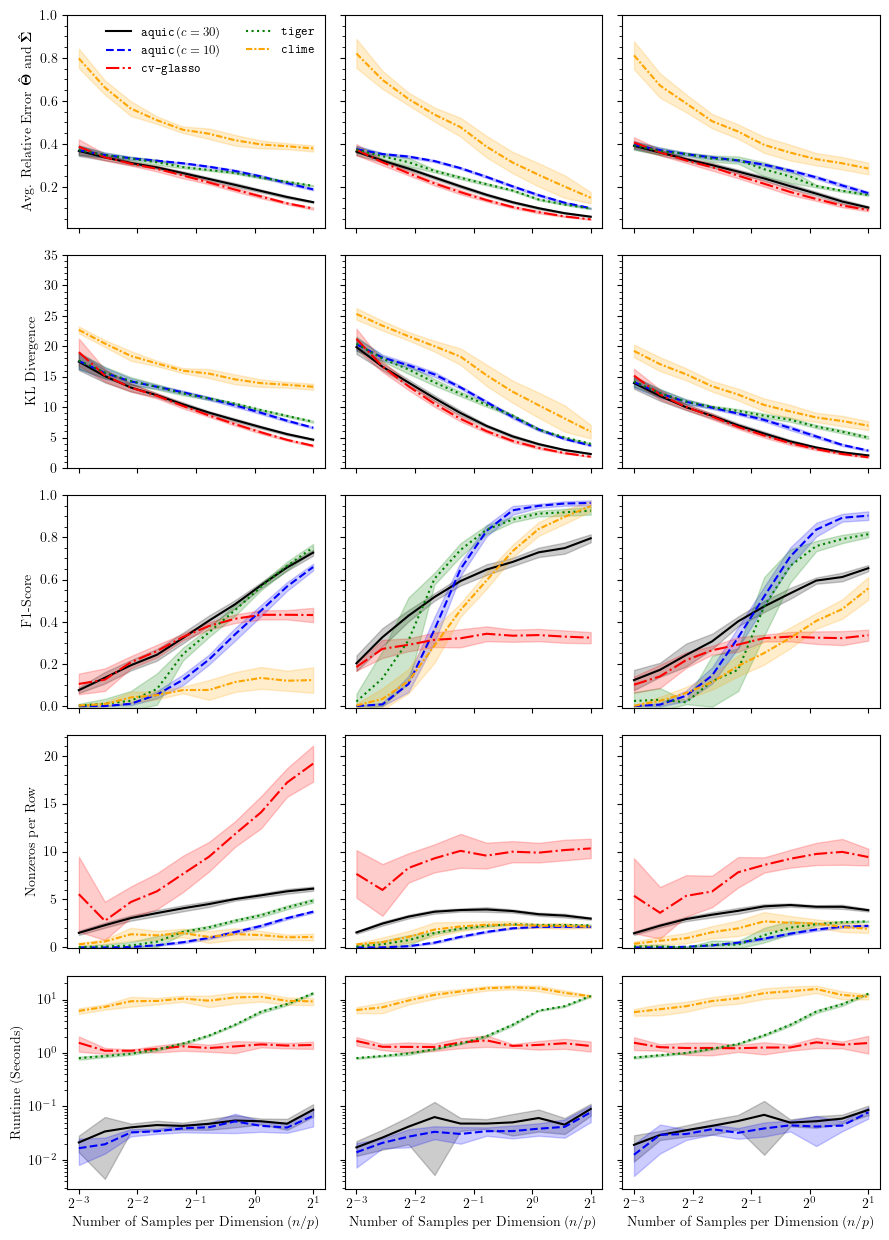

In [60]:
file_name = "data_err1_128"
[x_line, dataframe] = pd.read_pickle(file_name + ".pkl") 

line_style = ['-', '--', '-.', ':', (0, (3, 1, 1, 1))]

fig, axs = make_plot(5, 3, s=[1, 1], sharex=True, sharey='row')

std_band = 1
i = -1

i = i + 1
# Error in C and iC
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    m = (dataframe[data_type]['aquic1'].err_iC.mean(0) + dataframe[data_type]['aquic1'].err_C.mean(0)) / 2
    v = ((dataframe[data_type]['aquic1'].err_iC.std(0) + dataframe[data_type]['aquic1'].err_C.std(0)) / 2) * std_band
    axs[i, inx].plot(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic}\, (c=30)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black")
    
    # aquic2
    m = (dataframe[data_type]['aquic2'].err_iC.mean(0) + dataframe[data_type]['aquic2'].err_C.mean(0)) / 2
    v = ((dataframe[data_type]['aquic2'].err_iC.std(0) + dataframe[data_type]['aquic2'].err_C.std(0)) / 2) * std_band
    axs[i, inx].plot(x_line, m, color="blue", linestyle=line_style[1], label=r"$\texttt{aquic}\, (c=10)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue")
    
    # glasso
    m = (dataframe[data_type]['glasso'].err_iC.mean(0) + dataframe[data_type]['glasso'].err_C.mean(0)) / 2
    v = ((dataframe[data_type]['glasso'].err_iC.std(0) + dataframe[data_type]['glasso'].err_C.std(0)) / 2) * std_band
    axs[i, inx].plot(x_line, m, color="red", linestyle=line_style[2], label=r"$\texttt{cv-glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red")
    
    # tiger
    m = (dataframe[data_type]['tiger'].err_iC.mean(0) + dataframe[data_type]['tiger'].err_C.mean(0)) / 2
    v = ((dataframe[data_type]['tiger'].err_iC.std(0) + dataframe[data_type]['tiger'].err_C.std(0)) / 2) * std_band  
    axs[i, inx].plot(x_line, m, color="green", linestyle=line_style[3], label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green")
    
    # clime
    m = (dataframe[data_type]['clime'].err_iC.mean(0) + dataframe[data_type]['clime'].err_C.mean(0)) / 2
    v = ((dataframe[data_type]['clime'].err_iC.std(0) + dataframe[data_type]['clime'].err_C.std(0)) / 2) * std_band
    axs[i, inx].plot(x_line, m, color="orange", linestyle=line_style[4], label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="orange")

axs[i, 0].legend(loc='upper right', frameon=False, fontsize=9, ncol=2)

axs[i, 0].set_ylim([1e-2, 1e0])
axs[i, 0].set_ylabel(r"Avg. Relative Error $\mathbf{\hat{\Theta}}$ and $\mathbf{\hat{\Sigma}}$")
axs[i, 0].minorticks_on()


i = i + 1
# KL Divergence
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    
    # aquic1
    m = dataframe[data_type]['aquic1'].kl.mean(0)
    v = dataframe[data_type]['aquic1'].kl.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic} (c=30)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black")
    
    #aquic2
    m = dataframe[data_type]['aquic2'].kl.mean(0)
    v = dataframe[data_type]['aquic2'].kl.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="blue", linestyle=line_style[1], label=r"$\texttt{aquic} (c=10)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue")
    
    # glasso
    m = dataframe[data_type]['glasso'].kl.mean(0)
    v = dataframe[data_type]['glasso'].kl.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="red", linestyle=line_style[2], label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red")
    

    # tiger
    m = dataframe[data_type]['tiger'].kl.mean(0)
    v = dataframe[data_type]['tiger'].kl.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="green", linestyle=line_style[3], label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green")
    
    # clime
    m = dataframe[data_type]['clime'].kl.mean(0)
    v = dataframe[data_type]['clime'].kl.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="orange", linestyle=line_style[4], label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="orange")

axs[i, 0].set_ylim([0, 35])
axs[i, 0].set_ylabel(r'KL Divergence')
axs[i, 0].minorticks_on()
#axs[i, 0].legend(loc='upper right', frameon=False, fontsize=10, ncol=2)

i = i + 1
# F1 Score
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    m = dataframe[data_type]['aquic1'].f1.mean(0)
    v = dataframe[data_type]['aquic1'].f1.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic} (c=30)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black")
    
    # aquic2
    m = dataframe[data_type]['aquic2'].f1.mean(0)
    v = dataframe[data_type]['aquic2'].f1.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="blue", linestyle=line_style[1], label=r"$\texttt{aquic} (c=10)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue")
    
    # glasso
    m = dataframe[data_type]['glasso'].f1.mean(0)
    v = dataframe[data_type]['glasso'].f1.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="red", linestyle=line_style[2], label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red")
    
    # tiger
    m = dataframe[data_type]['tiger'].f1.mean(0)
    v = dataframe[data_type]['tiger'].f1.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="green", linestyle=line_style[3], label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green")
    
    # clime
    m = dataframe[data_type]['clime'].f1.mean(0)
    v = dataframe[data_type]['clime'].f1.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="orange", linestyle=line_style[4], label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="orange")

axs[i, 0].set_ylim([-0.01, 1])
axs[i, 0].set_ylabel(r'F1-Score')
axs[i, 0].minorticks_on()

i = i + 1
# Nonzeros per Row
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    m = dataframe[data_type]['aquic1'].nnz.mean(0)
    v = dataframe[data_type]['aquic1'].nnz.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic} (c=30)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black")
    
    # aquic2
    m = dataframe[data_type]['aquic2'].nnz.mean(0)
    v = dataframe[data_type]['aquic2'].nnz.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="blue", linestyle=line_style[1], label=r"$\texttt{aquic} (c=10)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue")
    
    # glasso
    m = dataframe[data_type]['glasso'].nnz.mean(0)
    v = dataframe[data_type]['glasso'].nnz.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="red", linestyle=line_style[2], label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red")
    
    # tiger
    m = dataframe[data_type]['tiger'].nnz.mean(0)
    v = dataframe[data_type]['tiger'].nnz.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="green", linestyle=line_style[3], label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green")
    
    # clime
    m = dataframe[data_type]['clime'].nnz.mean(0)
    v = dataframe[data_type]['clime'].nnz.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="orange", linestyle=line_style[4], label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="orange")

axs[i, 0].set_ylim([-.1, None])
axs[i, 0].set_ylabel(r'Nonzeros per Row')
axs[i, 0].minorticks_on()

i = i + 1
# Runtime
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    m = dataframe[data_type]['aquic1'].runtime.mean(0)
    v = dataframe[data_type]['aquic1'].runtime.std(0) * std_band

    axs[i, inx].loglog(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic} (c=30)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black")
    
    # aquic2
    m = dataframe[data_type]['aquic2'].runtime.mean(0)
    v = dataframe[data_type]['aquic2'].runtime.std(0) * std_band
    axs[i, inx].loglog(x_line, m, color="blue", linestyle=line_style[1], label=r"$\texttt{aquic} (c=10)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue")
    
    # glasso
    m = dataframe[data_type]['glasso'].runtime.mean(0)
    v = dataframe[data_type]['glasso'].runtime.std(0) * std_band
    axs[i, inx].loglog(x_line, m, color="red", linestyle=line_style[2], label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red")
    
    # tiger
    m = dataframe[data_type]['tiger'].runtime.mean(0)
    v = dataframe[data_type]['tiger'].runtime.std(0) * std_band
    axs[i, inx].loglog(x_line, m, color="green", linestyle=line_style[3], label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green")
    
    # clime
    m = dataframe[data_type]['clime'].runtime.mean(0)
    v = dataframe[data_type]['clime'].runtime.std(0) * std_band
    axs[i, inx].loglog(x_line, m, color="orange", linestyle=line_style[4], label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="orange")
    
    #axs[i, inx].set_xticks([.1,.5,1,1.5, 2])
    axs[i, inx].set_xlabel(r'Number of Samples per Dimension ($n/p$)')

axs[i, 0].set_ylabel(r'Runtime (Seconds)')
axs[i, 0].minorticks_on()
axs[i, 0].set_xscale('log', base=2)

# axs[i, 0].set_xticks(x_line)
# axs[i, 0].set_xticklabels([str(int(val)) for val in x_line])

fig.savefig("fig_data_err1.png", dpi=300)
fig_size_pixels = fig.get_size_inches()
print("Figure size (width x height in pixels):", fig_size_pixels, fig_size_pixels[1] / fig_size_pixels[0])

Figure size (width x height in pixels): [9 12.5] 1.3888888888888888


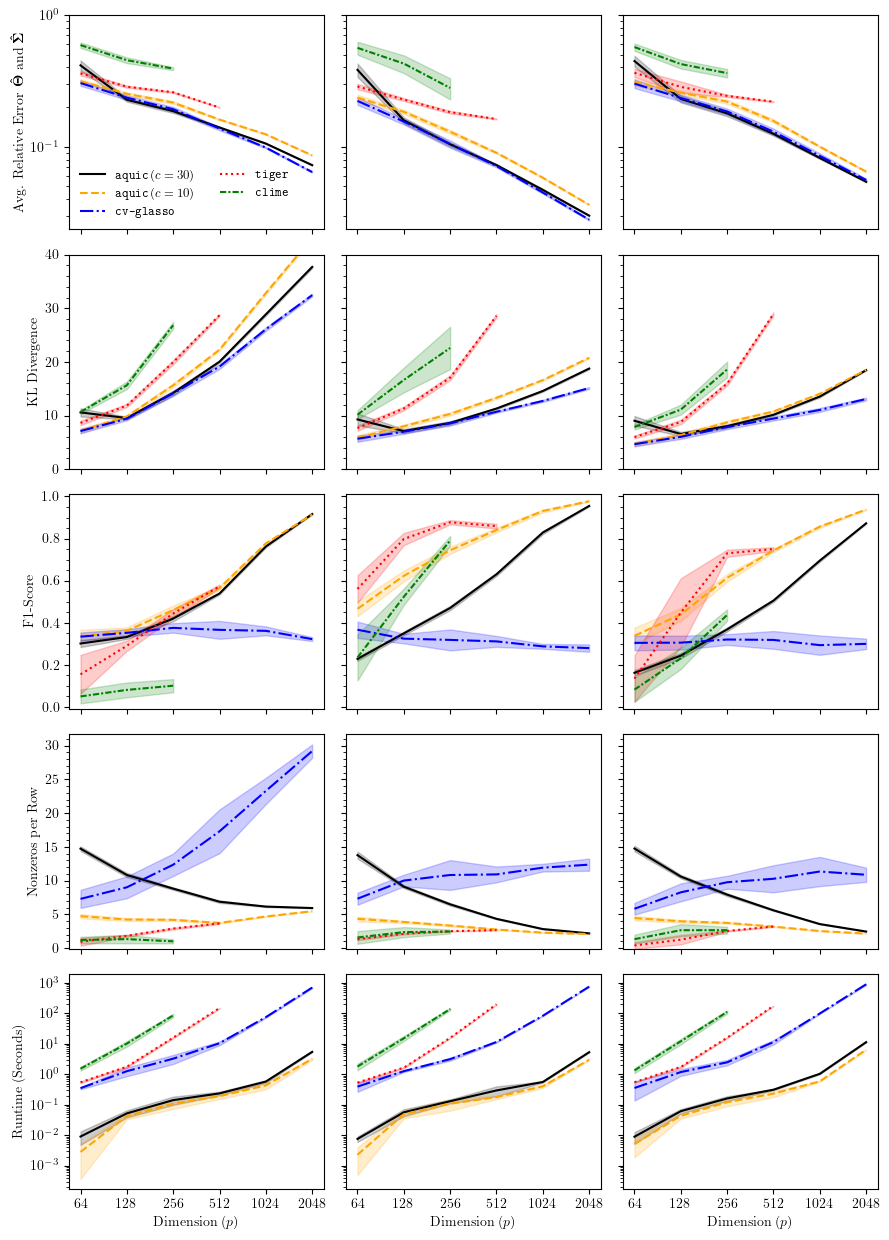

In [61]:
file_name = "data_err2_2"
line_style = ['-', '--', '-.', ':', (0, (3, 1, 1, 1))]

[x_line, dataframe] = pd.read_pickle(file_name + ".pkl") 

fig, axs = make_plot(5, 3, s=[1, 1], sharex=True, sharey='row')

std_band = 1
i = -1

i = i + 1
# Error in C and iC
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    m = (dataframe[data_type]['aquic1'].err_iC.mean(0) + dataframe[data_type]['aquic1'].err_C.mean(0)) / 2
    v = ((dataframe[data_type]['aquic1'].err_iC.std(0) + dataframe[data_type]['aquic1'].err_C.std(0)) / 2) * std_band
    axs[i, inx].semilogy(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic}\,(c=30)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black")
    
    # aquic2
    m = (dataframe[data_type]['aquic2'].err_iC.mean(0) + dataframe[data_type]['aquic2'].err_C.mean(0)) / 2
    v = ((dataframe[data_type]['aquic2'].err_iC.std(0) + dataframe[data_type]['aquic2'].err_C.std(0)) / 2) * std_band
    axs[i, inx].semilogy(x_line, m, color="orange", linestyle=line_style[1], label=r"$\texttt{aquic}\,(c=10)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="orange")
    
    # glasso
    m = (dataframe[data_type]['glasso'].err_iC.mean(0) + dataframe[data_type]['glasso'].err_C.mean(0)) / 2
    v = ((dataframe[data_type]['glasso'].err_iC.std(0) + dataframe[data_type]['glasso'].err_C.std(0)) / 2) * std_band
    axs[i, inx].semilogy(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{cv-glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue")
    
    # tiger
    m = (dataframe[data_type]['tiger'].err_iC.mean(0) + dataframe[data_type]['tiger'].err_C.mean(0)) / 2
    v = ((dataframe[data_type]['tiger'].err_iC.std(0) + dataframe[data_type]['tiger'].err_C.std(0)) / 2) * std_band  
    axs[i, inx].semilogy(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red")
    
    # clime
    m = (dataframe[data_type]['clime'].err_iC.mean(0) + dataframe[data_type]['clime'].err_C.mean(0)) / 2
    v = ((dataframe[data_type]['clime'].err_iC.std(0) + dataframe[data_type]['clime'].err_C.std(0)) / 2) * std_band
    axs[i, inx].semilogy(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green")


axs[i, 0].legend(loc='lower left', frameon=False, fontsize=9, ncol=2)

axs[i, 0].set_ylim([None, 1])
axs[i, 0].set_ylabel(r"Avg. Relative Error $\mathbf{\hat{\Theta}}$ and $\mathbf{\hat{\Sigma}}$")
axs[i, 0].minorticks_on()

i = i + 1
# KL Divergence
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    m = dataframe[data_type]['aquic1'].kl.mean(0)
    v = dataframe[data_type]['aquic1'].kl.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic}\,(c=30)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black")
    
    # aquic2
    m = dataframe[data_type]['aquic2'].kl.mean(0)
    v = dataframe[data_type]['aquic2'].kl.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="orange", linestyle=line_style[1], label=r"$\texttt{aquic}\,(c=10)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="orange")
    
    # glasso
    m = dataframe[data_type]['glasso'].kl.mean(0)
    v = dataframe[data_type]['glasso'].kl.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue")
    
    # tiger
    m = dataframe[data_type]['tiger'].kl.mean(0)
    v = dataframe[data_type]['tiger'].kl.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red")
    
    # clime
    m = dataframe[data_type]['clime'].kl.mean(0)
    v = dataframe[data_type]['clime'].kl.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green")

axs[i, 0].set_ylim([0, 40])
axs[i, 0].set_ylabel(r'KL Divergence')
axs[i, 0].minorticks_on()

i = i + 1
# F1 Score
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    m = dataframe[data_type]['aquic1'].f1.mean(0)
    v = dataframe[data_type]['aquic1'].f1.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black")
    
    # aquic2
    m = dataframe[data_type]['aquic2'].f1.mean(0)
    v = dataframe[data_type]['aquic2'].f1.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="orange", linestyle=line_style[1], label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="orange")
    
    # glasso
    m = dataframe[data_type]['glasso'].f1.mean(0)
    v = dataframe[data_type]['glasso'].f1.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue")
    
    # tiger
    m = dataframe[data_type]['tiger'].f1.mean(0)
    v = dataframe[data_type]['tiger'].f1.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red")
    
    # clime
    m = dataframe[data_type]['clime'].f1.mean(0)
    v = dataframe[data_type]['clime'].f1.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green")

axs[i, 0].set_ylim([-0.01, 1.01])
axs[i, 0].set_ylabel(r'F1-Score')
axs[i, 0].minorticks_on()

i = i + 1
# Nonzeros per Row
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    m = dataframe[data_type]['aquic1'].nnz.mean(0)
    v = dataframe[data_type]['aquic1'].nnz.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black")
    
    # aquic2
    m = dataframe[data_type]['aquic2'].nnz.mean(0)
    v = dataframe[data_type]['aquic2'].nnz.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="orange", linestyle=line_style[1], label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="orange")
    
    # glasso
    m = dataframe[data_type]['glasso'].nnz.mean(0)
    v = dataframe[data_type]['glasso'].nnz.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue")
    
    # tiger
    m = dataframe[data_type]['tiger'].nnz.mean(0)
    v = dataframe[data_type]['tiger'].nnz.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red")
    
    # clime
    m = dataframe[data_type]['clime'].nnz.mean(0)
    v = dataframe[data_type]['clime'].nnz.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green")

axs[i, 0].set_ylim([-.1, None])
axs[i, 0].set_ylabel(r'Nonzeros per Row')
axs[i, 0].minorticks_on()

i = i + 1
# Runtime
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    m = dataframe[data_type]['aquic1'].runtime.mean(0)
    v = dataframe[data_type]['aquic1'].runtime.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black")
    
    # aquic2
    m = dataframe[data_type]['aquic2'].runtime.mean(0)
    v = dataframe[data_type]['aquic2'].runtime.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="orange", linestyle=line_style[1], label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="orange")
    
    # glasso
    m = dataframe[data_type]['glasso'].runtime.mean(0)
    v = dataframe[data_type]['glasso'].runtime.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue")
    
    # tiger
    m = dataframe[data_type]['tiger'].runtime.mean(0)
    v = dataframe[data_type]['tiger'].runtime.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red")
    
    # clime
    m = dataframe[data_type]['clime'].runtime.mean(0)
    v = dataframe[data_type]['clime'].runtime.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green")
    
    axs[i, inx].set_xticks(x_line)
    axs[i, inx].set_xlabel(r'Dimension ($p$)')

# axs[i, 0].set_ylim([0, 1])
axs[i, 0].set_ylabel(r'Runtime (Seconds)')
axs[i, 0].minorticks_on()
axs[i, 0].set_xscale('log', base=2)

axs[i, 0].set_xticks(x_line)
axs[i, 0].set_xticklabels([str(int(val)) for val in x_line])

fig.savefig("fig_data_err2.png", dpi=300)
fig_size_pixels = fig.get_size_inches() 
print("Figure size (width x height in pixels):", fig_size_pixels,fig_size_pixels[1]/fig_size_pixels[0])